In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv("payload_full.csv")

# Display the first 10 rows
print(data.head(10))

                    payload  length attack_type label
0            c/ caridad s/n      14        norm  norm
1              campello, el      12        norm  norm
2                     40184       5        norm  norm
3          1442431887503330      16        norm  norm
4                     nue37       5        norm  norm
5               nuda drudes      11        norm  norm
6            tufts3@joll.rs      14        norm  norm
7                 22997112x       9        norm  norm
8  c/ del ferrocarril, 152,      24        norm  norm
9        arenas de san juan      18        norm  norm


In [2]:
print("Number of rows:", len(data))
print("Number of columns:", len(data.columns))

Number of rows: 31067
Number of columns: 4


In [3]:
print(data.columns)

Index(['payload', 'length', 'attack_type', 'label'], dtype='object')


In [4]:
print(data["attack_type"].value_counts())

norm              19304
sqli              10852
xss                 532
path-traversal      290
cmdi                 89
Name: attack_type, dtype: int64


In [5]:
data = data[data["attack_type"].isin(["norm", "sqli"])]

In [6]:
print(data["attack_type"].value_counts())

norm    19304
sqli    10852
Name: attack_type, dtype: int64


In [7]:
print(data.isnull().sum())

payload        0
length         0
attack_type    0
label          0
dtype: int64


In [8]:
data = data.drop_duplicates(subset=["payload"])

In [9]:
print("Rows after removing duplicates:", len(data))

Rows after removing duplicates: 30156


In [10]:
X = data["payload"]

In [11]:
y = data["label"]

In [12]:
X = data["payload"]
y = data["label"]

print(X.head())
print(y.head())

0      c/ caridad s/n
1        campello, el
2               40184
3    1442431887503330
4               nue37
Name: payload, dtype: object
0    norm
1    norm
2    norm
3    norm
4    norm
Name: label, dtype: object


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24124
Testing samples: 6032


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (24124, 264817)
Testing shape: (6032, 264817)


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [17]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

['norm' 'anom' 'norm' 'norm' 'norm' 'anom' 'norm' 'norm' 'anom' 'norm'
 'anom' 'norm' 'norm' 'anom' 'anom' 'norm' 'norm' 'norm' 'norm' 'anom']


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9991710875331565


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        anom       1.00      1.00      1.00      2171
        norm       1.00      1.00      1.00      3861

    accuracy                           1.00      6032
   macro avg       1.00      1.00      1.00      6032
weighted avg       1.00      1.00      1.00      6032



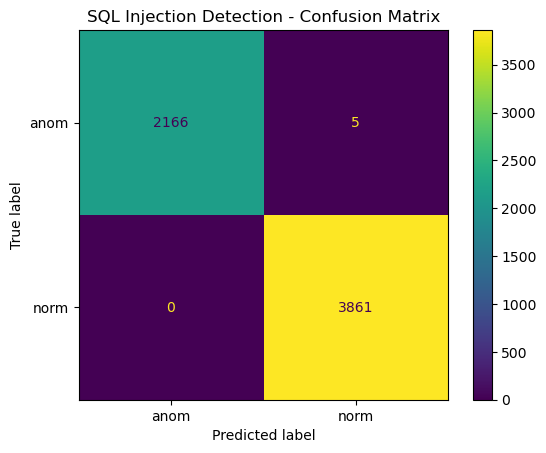

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("SQL Injection Detection - Confusion Matrix")
plt.show()

In [21]:
def detect_sqli(payload):
    payload_tfidf = vectorizer.transform([payload])
    prediction = model.predict(payload_tfidf)[0]
    return prediction

In [22]:
test_payloads = [
    "Koustav",
    "hello world",
    "12345",
    "' OR '1'='1",
    "admin'--",
    "' UNION SELECT username FROM users --"
]

for payload in test_payloads:
    result = detect_sqli(payload)
    print(payload, "=>", result)

Koustav => norm
hello world => norm
12345 => norm
' OR '1'='1 => anom
admin'-- => norm
' UNION SELECT username FROM users -- => anom


In [23]:
import pickle

with open("sqli_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model saved successfully!")

Model saved successfully!


In [24]:
print("Classes learned by the model:")
print(model.classes_)

Classes learned by the model:
['anom' 'norm']


In [25]:
print(data["label"].value_counts())

norm    19304
anom    10852
Name: label, dtype: int64


In [26]:
# Generate prediction probabilities

y_probabilities = model.predict_proba(X_test_tfidf)

print("Probability shape:", y_probabilities.shape)
print("First 5 probabilities:\n", y_probabilities[:5])

Probability shape: (6032, 2)
First 5 probabilities:
 [[1.76931919e-02 9.82306808e-01]
 [9.99826475e-01 1.73525387e-04]
 [1.80923084e-02 9.81907692e-01]
 [5.39264771e-02 9.46073523e-01]
 [9.34824793e-03 9.90651752e-01]]


In [27]:
# Calculate prediction confidence

import numpy as np

# Get the highest probability for each prediction
confidence_scores = np.max(y_probabilities, axis=1)

# Convert probabilities into percentages
confidence_percentages = confidence_scores * 100

# Display confidence for the first 5 predictions
for i in range(5):
    print(f"Sample {i + 1}:")
    print(f"Predicted class: {model.classes_[np.argmax(y_probabilities[i])]}")
    print(f"Confidence: {confidence_percentages[i]:.2f}%")
    print("-" * 30)

Sample 1:
Predicted class: norm
Confidence: 98.23%
------------------------------
Sample 2:
Predicted class: anom
Confidence: 99.98%
------------------------------
Sample 3:
Predicted class: norm
Confidence: 98.19%
------------------------------
Sample 4:
Predicted class: norm
Confidence: 94.61%
------------------------------
Sample 5:
Predicted class: norm
Confidence: 99.07%
------------------------------


In [28]:
# Check the order of the model classes
print("Model classes:", model.classes_)

Model classes: ['anom' 'norm']


In [29]:
# Calculate prediction confidence correctly

import numpy as np

# Get the index of the highest probability
predicted_indices = np.argmax(y_probabilities, axis=1)

# Convert indices into class labels
predicted_classes = model.classes_[predicted_indices]

# Get the highest probability for each sample
confidence_percentages = np.max(y_probabilities, axis=1) * 100

# Display the first 5 predictions
for i in range(5):
    print(f"Sample {i + 1}:")
    print(f"Predicted class: {predicted_classes[i]}")
    print(f"Confidence: {confidence_percentages[i]:.2f}%")
    print("-" * 30)

Sample 1:
Predicted class: norm
Confidence: 98.23%
------------------------------
Sample 2:
Predicted class: anom
Confidence: 99.98%
------------------------------
Sample 3:
Predicted class: norm
Confidence: 98.19%
------------------------------
Sample 4:
Predicted class: norm
Confidence: 94.61%
------------------------------
Sample 5:
Predicted class: norm
Confidence: 99.07%
------------------------------


In [30]:
# Identify low-confidence predictions

confidence_threshold = 80

# Find predictions with confidence below 80%
low_confidence_indices = np.where(
    confidence_percentages < confidence_threshold
)[0]

print("Total test samples:", len(confidence_percentages))
print("Low-confidence predictions:", len(low_confidence_indices))
print(
    "Low-confidence percentage:",
    (len(low_confidence_indices) / len(confidence_percentages)) * 100,
    "%"
)

Total test samples: 6032
Low-confidence predictions: 106
Low-confidence percentage: 1.7572944297082227 %


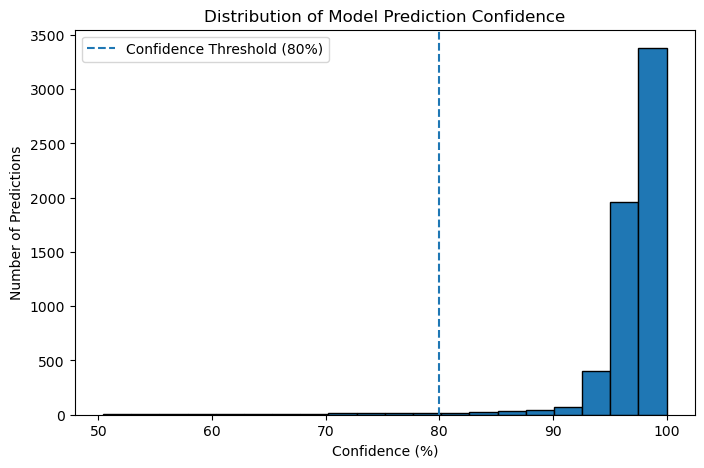

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    confidence_percentages,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    x=80,
    linestyle="--",
    label="Confidence Threshold (80%)"
)

plt.xlabel("Confidence (%)")
plt.ylabel("Number of Predictions")
plt.title("Distribution of Model Prediction Confidence")

plt.legend()
plt.show()

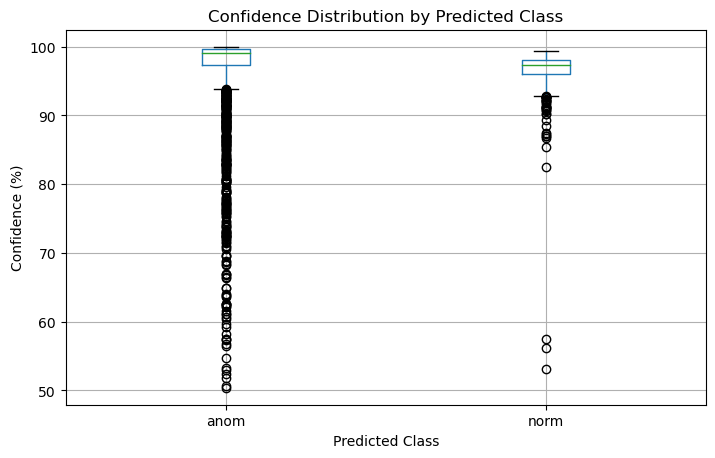

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

confidence_df = pd.DataFrame({
    "Predicted Class": predicted_classes,
    "Confidence": confidence_percentages
})

confidence_df.boxplot(
    column="Confidence",
    by="Predicted Class",
    figsize=(8, 5)
)

plt.title("Confidence Distribution by Predicted Class")
plt.suptitle("")
plt.xlabel("Predicted Class")
plt.ylabel("Confidence (%)")
plt.show()

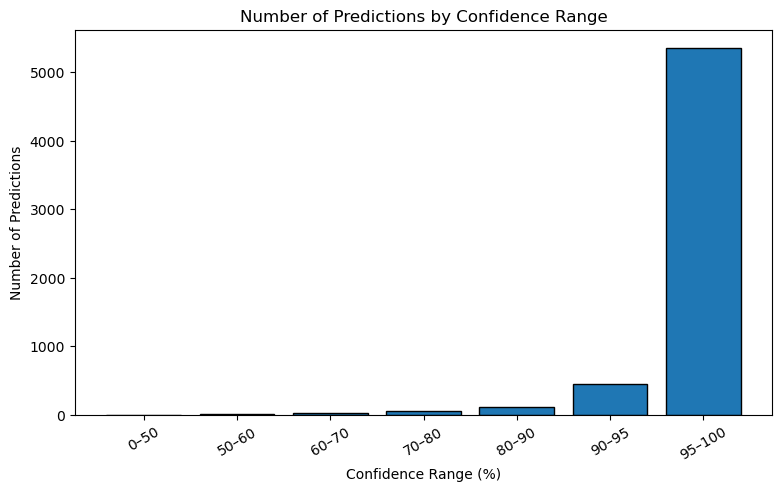

In [33]:
confidence_bins = [0, 50, 60, 70, 80, 90, 95, 100]
confidence_labels = [
    "0–50", "50–60", "60–70",
    "70–80", "80–90", "90–95", "95–100"
]

confidence_categories = pd.cut(
    confidence_percentages,
    bins=confidence_bins,
    labels=confidence_labels,
    include_lowest=True
)

confidence_counts = confidence_categories.value_counts().sort_index()

plt.figure(figsize=(9, 5))

plt.bar(
    confidence_counts.index.astype(str),
    confidence_counts.values,
    edgecolor="black"
)

plt.xlabel("Confidence Range (%)")
plt.ylabel("Number of Predictions")
plt.title("Number of Predictions by Confidence Range")
plt.xticks(rotation=30)
plt.show()

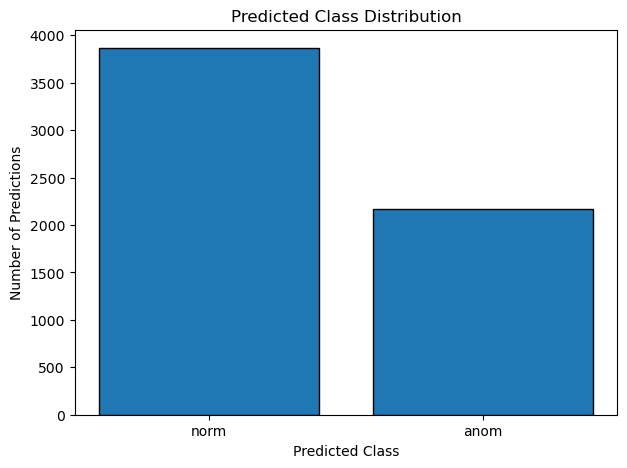

In [34]:
class_counts = pd.Series(predicted_classes).value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    class_counts.index,
    class_counts.values,
    edgecolor="black"
)

plt.xlabel("Predicted Class")
plt.ylabel("Number of Predictions")
plt.title("Predicted Class Distribution")
plt.show()

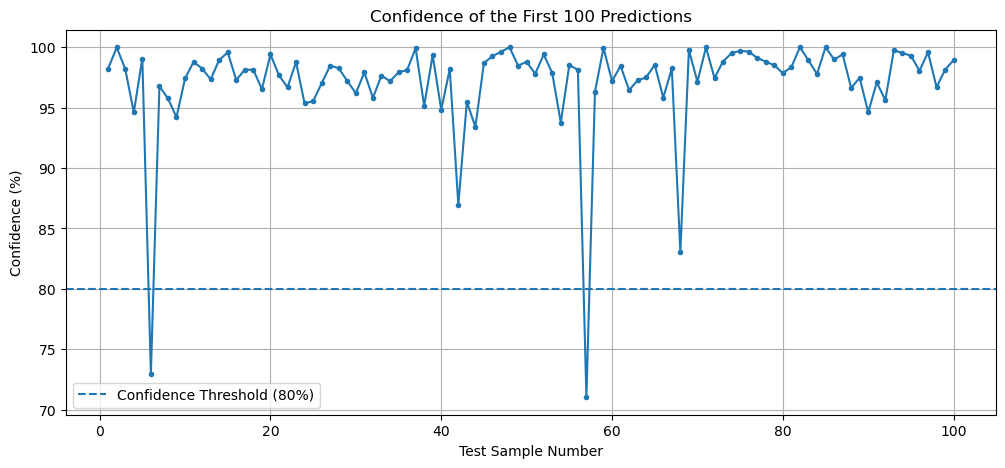

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(1, 101),
    confidence_percentages[:100],
    marker="o",
    markersize=3
)

plt.axhline(
    y=80,
    linestyle="--",
    label="Confidence Threshold (80%)"
)

plt.xlabel("Test Sample Number")
plt.ylabel("Confidence (%)")
plt.title("Confidence of the First 100 Predictions")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# Create a confidence analysis DataFrame

analysis_df = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": predicted_classes,
    "Confidence (%)": confidence_percentages
})

# Check whether each prediction is correct
analysis_df["Correct"] = (
    analysis_df["Actual Class"] == analysis_df["Predicted Class"]
)

# Display the first 10 rows
analysis_df.head(10)

,Actual Class,Predicted Class,Confidence (%),Correct
0,norm,norm,98.230681,True
1,anom,anom,99.982647,True
2,norm,norm,98.190769,True
3,norm,norm,94.607352,True
4,norm,norm,99.065175,True
5,anom,anom,72.986813,True
6,norm,norm,96.766204,True
7,norm,norm,95.764763,True
8,anom,anom,94.200854,True
9,norm,norm,97.411689,True


In [37]:
# Step 1: Comparing Different Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import time

# Create the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Multinomial Naive Bayes": MultinomialNB()
}

# Store the results
results = []

# Train and evaluate each model
for model_name, classifier in models.items():

    print(f"\nTraining {model_name}...")

    # Record starting time
    start_time = time.time()

    # Train the model
    classifier.fit(X_train_tfidf, y_train)

    # Make predictions
    y_pred = classifier.predict(X_test_tfidf)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Calculate training time
    training_time = time.time() - start_time

    # Store the results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Training Time (seconds)": training_time
    })

    # Display classification report
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred))

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Display model comparison
print("\n========== MODEL COMPARISON ==========")
display(results_df)


Training Logistic Regression...

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

        anom       1.00      1.00      1.00      2171
        norm       1.00      1.00      1.00      3861

    accuracy                           1.00      6032
   macro avg       1.00      1.00      1.00      6032
weighted avg       1.00      1.00      1.00      6032


Training Linear SVM...

Classification Report for Linear SVM:
              precision    recall  f1-score   support

        anom       1.00      1.00      1.00      2171
        norm       1.00      1.00      1.00      3861

    accuracy                           1.00      6032
   macro avg       1.00      1.00      1.00      6032
weighted avg       1.00      1.00      1.00      6032


Training Multinomial Naive Bayes...

Classification Report for Multinomial Naive Bayes:
              precision    recall  f1-score   support

        anom       1.00      1.00      1.00      2171
    

,Model,Accuracy,Training Time (seconds)
0,Logistic Regression,0.999171,3.098028
1,Linear SVM,0.999668,0.372554
2,Multinomial Naive Bayes,0.998674,0.169712


In [ ]:
# Step 2: Checking for Data Leakage

# Convert training and testing payloads into sets
train_payloads = set(X_train)
test_payloads = set(X_test)

# Find overlapping payloads
overlapping_payloads = train_payloads.intersection(test_payloads)

print("Number of unique training payloads:", len(train_payloads))
print("Number of unique testing payloads:", len(test_payloads))
print("Number of overlapping payloads:", len(overlapping_payloads))

# Calculate overlap percentage
overlap_percentage = (
    len(overlapping_payloads) / len(test_payloads)
) * 100

print(f"Data overlap percentage: {overlap_percentage:.4f}%")